In [1]:
from IPython.display import Image

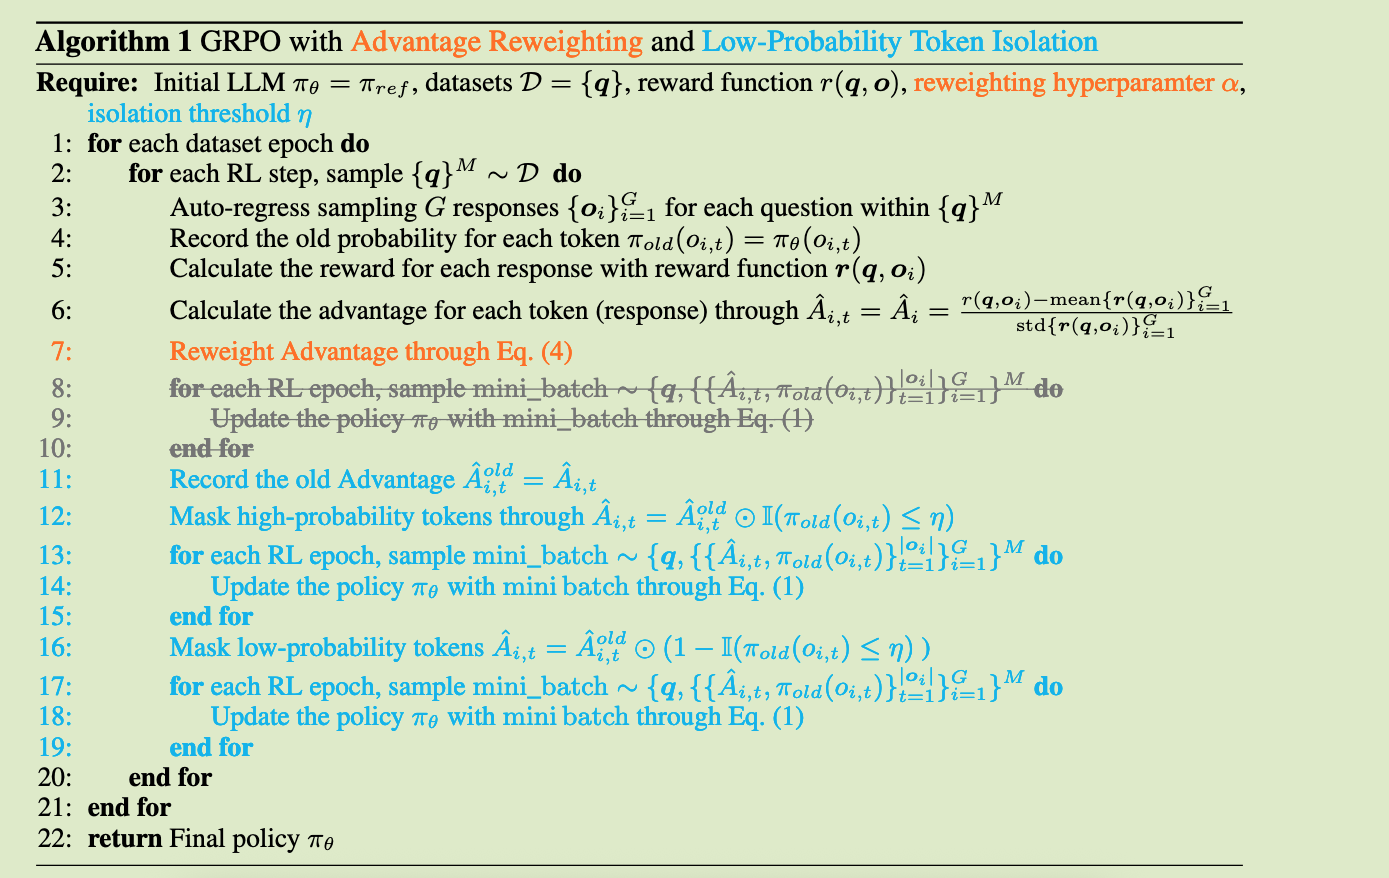

In [2]:
Image(filename='./GRPOWithReweighting.png')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformer import AutoModelForCausalLM,AutoTokenizer
from typing import List,Dict,Tuple,Optional
import numpy as np

class GRPOWithReweighting:
    '''
    GRPO with Advantage Reweighting and Low-Probability Token Isolation
    '''
    def __init__(
        self,
        model_path:str,
        learning_rate:float = 1e-6,
        epsilon:float = 0.2, # PPO裁剪参数
        alpha:float = 0.5,   # 优势重加权参数
        eta:float = 0.1,     # 低概率token隔离阀值
        kl_coef:float = 0.001,
        gamma:float = 0.99,  # 折扣因子
    ):
        # 初始化模型
        self.policy = AutoModelForCausalLM.from_pretrained(model_path)
        self.reference = AutoModelForCausalLM.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        
        # 冻结参考模型
        for param in self.reference.parameters():
            param.required_grad = False
            
        # 优化器
        self.optimizer = torch.optim.Adam(self.policy.parameters(),lr=learning_rate)
        
        # 超参数
        self.epsilon = epsilon
        self.alpha = alpha
        self.eta = eta
        self.kl_coef = kl_coef
        self.gamma = gamma
        
    def generate_reponses(
        self,
        questions:List[str],
        num_response_per_question:int = 4,
        max_lenghth: int = 512,
    )-> Tuple[List[str],List[torch.tensor],List[torch.Tensor]]:
        '''
        为每个问题自回归采样G个回答
        
        Returns:
            responses:生成的回答文本
            response_tokens: 每个回答的token序列
            log_probs: 每个token的log概率
            
        '''
        
        self.policy.eval()
        all_responses = []
        all_tokens = []
        all_log_probs = []
        
        with torch.no_grad():
            for question in questions:
                inputs = self.tokenizer(question,return_tensors='pt')
                question_tokens = inputs.input_ids
                
                for _ in range(num_response_per_question):
                    # 自回归采样
                    generated = self.policy.generate(
                        question_tokens,
                        max_new_tokens=max_length,
                        do_sample=True,
                        temperature=1.0,
                        pad_token_id=self.tokenizer.pad_token_id,
                        output_scores=True,
                        return_dict_in_generate=True
                    )
                    
                    # 提取生成的token和对应的log概率
                    response_tokens=generated.sequences[:,question_tokens.shape[1]:]
                    response_text = self.tokenizer.decode(response_tokens[0],skip_special_tokens=True)
                    
                    # 计算每个token的log概率
                    with torch.no_grad():
                        outputs = self.policy(generated.sequences)
                        logits = outputs.logits[:,question_tokens.shape[1]-1:-1,:]
                        log_probs = F.log_softmax(logits,dim=-1)
                        token_log_probs = torch.gather(
                            log_probs,
                            dim=-1,
                            index=response_tokens.unsqueeze(-1)
                        ).squeeze(-1)
                        
                    all_responses.append(response_text)
                    all_tokens.append(response_token[0])
                    all_log_probs.append(token_log_probs[0])
                    
            return all_responses,all_tokens,all_log_probs
            
    def compute_rewards(
        self,
        question:List[str],
        responses:List[str]
    ) -> torch.Tensor:
        '''
        计算每个回答的奖励
        
        Args:
            questions:原始问题列表（重复G次，对应每个回答）
            responses:生成的回答列表
            
        Returns:
            每个token位置的奖励（标量奖励广播到真个序列)
        '''
        # 这里需要实现具体的奖励函数
        # 示例：使用了一个简单的奖励模型或规则
        
        rewards = []
        for q,r in zip(questions,responses):
            # 替换为实际的奖励计算逻辑
            reward = self.custom_reward_function(q,r)
            rewards.append(rewards)
            
    def custom_reward_function(self, question: str, response: str) -> float:
        """
        自定义奖励函数，根据具体任务实现
        例如：正确性、格式、长度等
        """
        # TODO: 实现具体任务的奖励逻辑
        # 示例：返回随机奖励
        return np.random.random()
    
    def compute_advantages(
        self,
        rewwards:torch.Tensor,
        num_groups:int,
        group_size:int,
    )-> torch.Tensor:
        '''
        计算优势函数
        
        args：
            rewards： 所有回答的奖励[M * G]
            num_groups: 问题数量 M
            group_size: 每个问题的回答数 G
            
        Returns：
            标准化后的优势值
        '''
        advantages = []
        for i in range(num_groups):
            group_rewards = rewards[i * group_size:(i+1) * group_size]
            mean_reward = group_rewards.mean()
            std_reward = group_rewards.std() + 1e-8
            
            # 标准化优势
            group_adv = (group_rewards - mean_reward) / std_reward
            advantages.append(group_adv)
            
        return torch.cat(advantages)
    
    def reweight_advantages(
        self,
        advantages:torch.Tensor,
        old_log_probs:torch.Tensor,
        current_log_probs:torch.Tensor
    )-> torch.Tensor:
        '''
        优势重加权
        
        公式： A_reweighted = A * min(1.0,exp(π_current - π_old))
        '''
        log_prob_ratio = current_log_probs - old_log_probs
        weight = torch.exp(self.alpha * log_prob_ratio)
        weight = torch.clamp(weight,max = 1.0)
        
        return advantages * weight
    
    def compute_policy_loss(
        self,
        advantages:torch.Tensor,
        old_log_probs:torch.Tensor,
        current_log_probs;torch.Tensor,
        mask:Optional[torch.Tensor] = None
    )-> torch.Tensor:
        '''
        计算策略损失
        L_clip(θ) = E[r(θ)A, clip(r(θ),1-1-ε, 1+ε)A)]
        
        '''
        ratio = torch.exp(current_log_probs - old_log_probs)
        
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratio, 1- self.epsilon,1 + self.epsilon) * advantages
        
        loss = - torch.min(surr1,surr2)
        
        if mask is not None:
            loss = loss * mask
        return loss.mean()
    
    
    def compute_kl_loss(self,current_logits,reference_logits)->torch.Tensor:
        '''
        计算KL散度损失，防止策略偏离参考模型过远
        '''
        kl_div = F.kl_div(
            F.log_softmax(current_logtis,dim=-1),
            F.softmax(reference_logtis,dim=-1),
            reduction='batchmean'
        )
        return self.kl_coef * kl_div
    
    def mask_high_probability_tokens(
        self,
        advantages:torch.Tensor,
        log_probs:torch.Tensor,
        mask_mode:str = 'high' # high or low 
    )-> torch.Tensor:
        '''
        掩码高概率或低概率token
        
        Args:
            advantages: 原始优势值
            log_probs: token的log概率
            mask_mode:'high' 掩码高概率token，'low'掩码低概率token
            
        Returns:
            掩码后的优势值
        '''
        probs = torch.exp(log_probs)
        if mask_model == 'high':
            # 掩码高概率token(π > η)
            mask = (probs <= self.eta).float()
        else： # low
            # 掩码低概率token(π ≤ η)
            mask = (probs > self.eta).float()
        return advantages * mask
    
    def train_step(
        self,
        questions:List[str],
        num_epochs_per_step:int = 3, # 它表示在每一轮采样数据之后，重复使用这批数据进行多少次策略更新的轮数
        num_response_per_question:int = 4,
        batch_size:int = 32
    ):
        '''
        执行完整的训练步骤
        '''
        M = len(questions)  # 问题的数量
        G = num_responses_per_question # 每个问题的回答数
        
        # 生成G个回答
        responses,response_tokens,old_log_probs = self.generate_reponses(
            questions,G
        )
        
        # 将列表 questions 中的每一个元素都重复 G 次，然后生成一个新的列表。
        # ["问题A", "问题A", "问题A", "问题B", "问题B", "问题B"]
        
        expanded_questions = [q for q in questions for _ in range(G)]
        
        # 计算奖励
        rewards = self.compute_rewards(expanded_questions,responses)
        
        # 计算优势
        advantages = self.compute_advantages(rewards,M,G)
        
        # 记录旧的优势值用于后续
        old_advantages = advantages.clone()
        
        # 准备训练数据
        train_data = []
        for i ,(q,r,tokens,log_probs) in numerate(zip(
            expanded_questions,responses,response_tokens,old_log_probs
        )):
            train_data.append({
                'question':q,
                'response':r
                'tokens':tokens
                'old_log_probs':log_probs,
                'advantage':advantages[i]
            })
        
        # 优势重加权（在mini-batch内计算）
        # reweighted advantage
        
        for epoch in range(num_epochs_per_step):
            '''
            标准的“随机小批量梯度下降”。它通过先打乱数据索引，再按固定大小切片的方式，
            确保模型在每一轮训练中都能以随机的顺序、分批地学习数据，从而避免模型记住样本的顺序。
            '''
            # 随机采样min-batch
            indices = np.random.permutation(len(train_data)) # 生成随机排列 可能的输出: [2 0 3 1 4]
            for start_idx in range(0,len(train_data),batch_size):
                batch_indices = indices[start_idx:start_idx + batch_size]
                batch = [train_data[i]] for i in batch_indices
                
                '''
                这段代码的核心目的是计算模型对给定文本序列的“对数概率”。
                简单来说，就是评估模型对一段已知文本的“认可程度”或“预测准确性”。
                它通过遍历批次中的每个样本，让模型逐个预测下一个词，并计算实际出现的词的概率。
                '''
                # 计算当前策略的log概率
                current_log_probs = []
                for item in batch:
                    with torch.no_grad():
                        outputs = self.policy(item['tokens'].unsqueeze(0))
                        logits = outputs.logits[:,:-1,:]
                        log_probs = F.log_softmax(logits,dim=-1)
                        token_log_probs = torch.gather(
                            log_probs,
                            dim=-1,
                            index = item['tokens'][1:].unsqueeze(0).unsqueeze(-1)
                        ).squeeze()
                    current_log_probs.append(token_log_probs)
                
                # 重加权优势
                batch_advantages = torch.stack([item['advantage'] for item in batch])
                batch_old_log_probs = torch.stack([item['old_log_probs'] for item in batch])
                
                batch_current_log_probs = torch.stack(current_log_probs)
                
                # 确保维度匹配（处理不同长度的序列）
                min_len = min(batch_old_log_probs.shape[1],batch_current_log_probs.shape[1])
                
                batch_old_log_probs = batch_old_log_probs[:,:min_len]
                batch_current_log_probs = batch_current_log_probs[:,:min_len]
                batch_advantages = batch_advantages[:,:min_len]
                
                # 优势重加权
                reweighted_advantages = self.reweight_advantages(
                    batch_advantages,batch_old_log_probs,batch_current_log_probs
                )
                
                # 计算策略损失
                policy_loss = self.compute_policy_loss(
                    reweighted_advantages,
                    batch_old_log_probs,
                    batch_current_log_probs
                )
                        
                # 可选：添加KL损失
                # kl_loss = self.compute_kl_loss(current_logits,reference_logtis)
                # total_loss = policy_loss + kl_loss
                total_loss = policy_loss
                
                # 反向传播
                self.optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.policy.parameters(),1.0)
                self.optimizer.step()
        
        # 掩码高概率token
        masked_advantages_high =self.mask_high_probability_tokens(
            old_advantages,
            old_log_probs,
            mask_mode = 'high'
        )
        
        self._train_with_masked_advantages(
            train_data,masked_advantages_high,num_epochs_per_step,batch_size
        )
        
        # 掩码低概率token
        masked_advantages_low = self.mask_high_probability_tokens(
            old_advantages,
            old_log_probs,
            mask_mode = 'low'
        )
                
        self._train_with_masked_advantages(
            train_data, masked_advantages_low, num_epochs_per_step, batch_size
        )
        
    def _train_with_masked_advantages(
        self,
        train_data:List[Dict],
        masked_advantages:torch.Tensor,
        num_epochs:int,
        batch_size:int,
    ):
        '''
        使用掩码后的优势值进行训练
        '''
        # 更新数据中的优势值
        for i,item in enumerate(train_data):
            item['advantage'] = masked_advantages[i]
            
        for epoch in range(num_epochs):
            indices = np.random.permutaion(len(train_data))
            for start_idx in range(0,len(train_data),batch_size):
                batch_indices = indices[start_idx:start_idx+batch_size]
                batch = [train_data[i] for i in batch_indices]
            
                # 计算当前策略的log概率
                current_log_probs = []
                for item in batch:
                    with torch.no_grad():
                        outputs = self.policy(item['tokens'].unsqueeze(0))
                        logits = outputs.logits[:,:-1,:]
                        log_probs = F.log_softmax(logits,dim=-1)
                        token_log_probs = torch.gather(
                            log_probs,
                            dim=-1,
                            index=item['tokens'][1:].unsqueeze(0).unsqueeze(-1)
                        ).squeeze()
                    current_log_probs.append(token_log_probs)
                    
            
            batch_advantages = torch.stack([item['advantage'] for item in batch])
            batch_old_log_probs = torch.stack([item['old_log_probs'] for item in batch])
            batch_current_log_probs = torch.stack(current_log_probs)
                
            min_len = min(batch_old_log_probs.shape[1], batch_current_log_probs.shape[1])
            batch_old_log_probs = batch_old_log_probs[:, :min_len]
            batch_current_log_probs = batch_current_log_probs[:, :min_len]
            batch_advantages = batch_advantages[:, :min_len]
                
            policy_loss = self.compute_policy_loss(
                batch_advantages, batch_old_log_probs, batch_current_log_probs
            )
                
            self.optimizer.zero_grad()
            policy_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
            self.optimizer.step()
        
        
def train_grpo_with_reweighting():
    '''
    完整的训练流程示例
    '''
    # 初始化模型
    grpo_trainer = GRPOWithReweighting(
        model_path = 'Qwen/Qwen2-1.5B-Instruct',
        learning_rate = 1e-6,
        alpha=0.5,
        eta=0.1
    )
    
    # 准备数据集
    train_questions = [
        "What is 2+2?",
        "Solve for x: 2x + 3 = 7",
        "What is the capital of France?", 
    ]
    
    # 训练循环
    num_epochs = 10
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        
        # 对每个batch执行训练
        batch_size = 4
        for i in range(0,len(train_questions),batch_size):
            batch_questions = train_questions[i:i+batch_size]
            
            grpo_trainer.train_step(
                questions = batch_questions,
                num_epochs_per_step = 3,
                num_response_per_question =4,
            )
            # 定期保存模型
            if i % 100 == 0:
                torch.save(
                    grpo.trainer.policy.state_dict(),
                    f"checkpoint_epoch{epoch}_step{i}.pt"
                )
    # 返回最终策略
    return grpo_trainer.policy

if __name__ == '__mian__':
    final_policy = train_grpo_with_reweighting()